# PPO Clipping Function — Interactive Demo

In PPO, the policy gradient loss uses a **clipped surrogate objective** to prevent the updated policy from moving too far from the old policy in a single step.

The loss for a single token is:

$$L^{\text{CLIP}}(\theta) = \min\!\Big(\underbrace{r_t(\theta)\,\hat{A}_t}_{\text{unclipped}},\;\underbrace{\operatorname{clip}\!\left(r_t(\theta),\,1-\varepsilon,\,1+\varepsilon\right)\hat{A}_t}_{\text{clipped}}\Big)$$

where the **probability ratio** is:
$$r_t(\theta) = \frac{\pi_\theta(a_t \mid s_t)}{\pi_{\theta_{\text{old}}}(a_t \mid s_t)}$$

- $r_t = 1$ means the new policy assigns the same probability as the old one (no change)
- $r_t > 1$ means the new policy has *increased* the probability of this action
- $r_t < 1$ means the new policy has *decreased* the probability of this action

$\varepsilon$ is a small hyperparameter (typically **0.1** or **0.2**) that controls the allowed range of change.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({'font.size': 13, 'figure.dpi': 120})

## 1. What does `clip(r, 1-ε, 1+ε)` do?

The `clip` function simply **clamps** $r$ into the interval $[1-\varepsilon,\; 1+\varepsilon]$:

$$\operatorname{clip}(r, 1-\varepsilon, 1+\varepsilon) = \begin{cases} 1-\varepsilon & \text{if } r < 1-\varepsilon \\ r & \text{if } 1-\varepsilon \le r \le 1+\varepsilon \\ 1+\varepsilon & \text{if } r > 1+\varepsilon \end{cases}$$

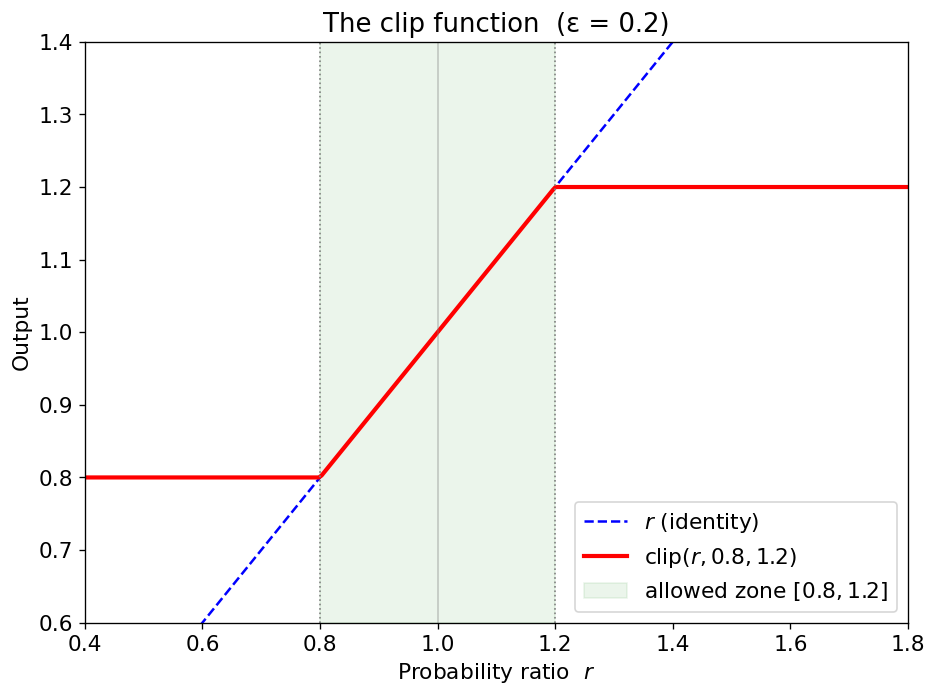

In [6]:
eps = 0.2
r = np.linspace(0.4, 1.8, 300)
clipped = np.clip(r, 1 - eps, 1 + eps)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(r, r,       'b--', lw=1.5, label='$r$ (identity)')
ax.plot(r, clipped, 'r-',  lw=2.5, label=f'clip$(r, {1-eps}, {1+eps})$')
ax.axvline(1 - eps, color='gray', lw=1, ls=':')
ax.axvline(1 + eps, color='gray', lw=1, ls=':')
ax.axvline(1.0,     color='gray', lw=1, ls='-', alpha=0.4)
ax.fill_betweenx([0.6, 1.4], 1 - eps, 1 + eps, alpha=0.08, color='green',
                 label=f'allowed zone $[{1-eps}, {1+eps}]$')
ax.set_xlabel('Probability ratio  $r$')
ax.set_ylabel('Output')
ax.set_title(f'The clip function  (ε = {eps})')
ax.legend()
ax.set_xlim(0.4, 1.8)
ax.set_ylim(0.6, 1.4)
plt.tight_layout()
plt.show()

**Reading the plot:**
- Inside the green zone ($1-\varepsilon \le r \le 1+\varepsilon$): `clip` returns $r$ unchanged.
- Outside the zone: `clip` **floors** or **caps** $r$ at the boundary.
- The dashed blue line ($y = r$) shows the unclipped ratio for comparison.

## 2. The Full Clipped Objective — Two Cases

The PPO loss is $\min(r\hat{A},\; \text{clip}(r,1-\varepsilon,1+\varepsilon)\hat{A})$.
The behaviour depends on the **sign of the advantage** $\hat{A}$.

### Case A — Positive Advantage ($\hat{A} > 0$): this was a *good* action, we want to increase its probability

| ratio $r$ | unclipped $r\hat{A}$ | clipped term | $\min(\cdot)$ | effect |
|---|---|---|---|---|
| $r < 1-\varepsilon$ | small | $(1-\varepsilon)\hat{A}$ | unclipped | freely increase prob |
| $1-\varepsilon \le r \le 1+\varepsilon$ | medium | $r\hat{A}$ (same) | either | normal gradient |
| $r > 1+\varepsilon$ | large | $(1+\varepsilon)\hat{A}$ | **clipped** | **gradient = 0, stop!** |

→ When $\hat{A} > 0$ and the policy has **already increased** the probability a lot ($r > 1+\varepsilon$), the clip kicks in and **blocks further increase**.

### Case B — Negative Advantage ($\hat{A} < 0$): this was a *bad* action, we want to decrease its probability

| ratio $r$ | unclipped $r\hat{A}$ | clipped term | $\min(\cdot)$ | effect |
|---|---|---|---|---|
| $r < 1-\varepsilon$ | less negative | $(1-\varepsilon)\hat{A}$ | **clipped** | **gradient = 0, stop!** |
| $1-\varepsilon \le r \le 1+\varepsilon$ | medium negative | $r\hat{A}$ (same) | either | normal gradient |
| $r > 1+\varepsilon$ | very negative | $(1+\varepsilon)\hat{A}$ | unclipped | freely decrease prob |

→ When $\hat{A} < 0$ and the policy has **already decreased** the probability a lot ($r < 1-\varepsilon$), the clip kicks in and **blocks further decrease**.

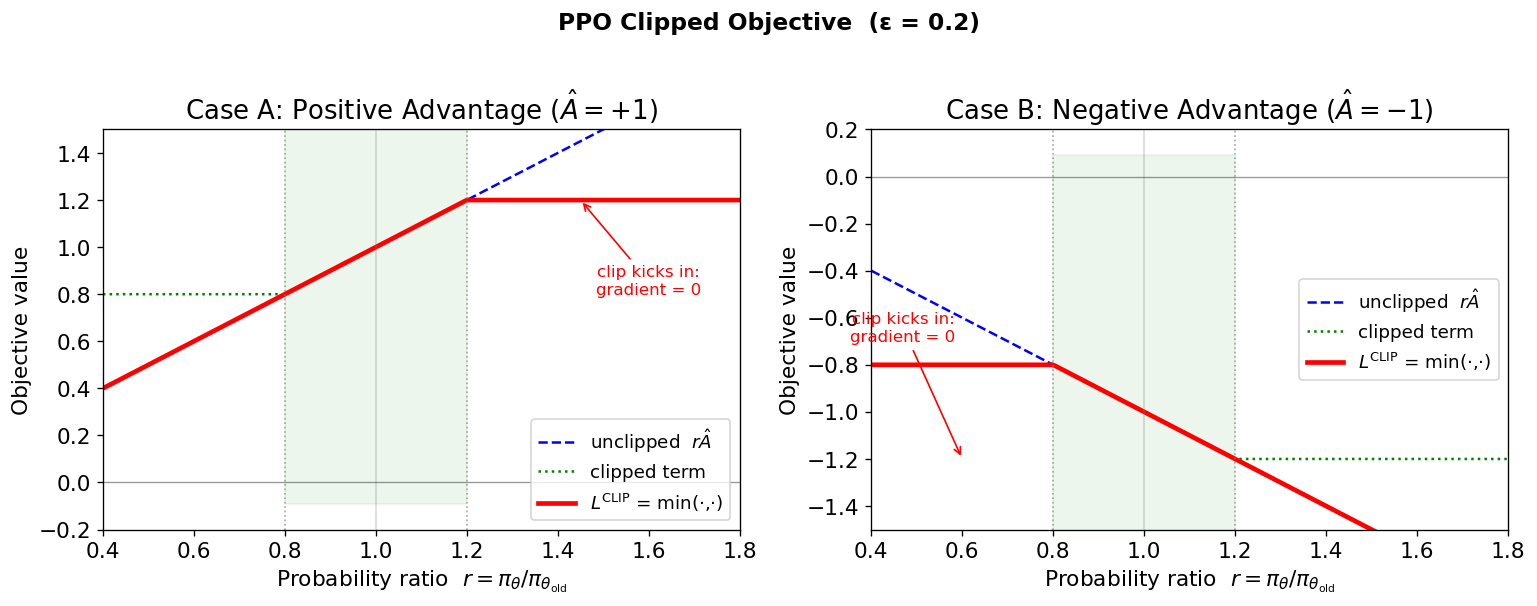

In [7]:
def ppo_clip_objective(r, A_hat, eps=0.2):
    """Compute the PPO clipped objective for a single token."""
    unclipped = r * A_hat
    clipped   = np.clip(r, 1 - eps, 1 + eps) * A_hat
    return np.minimum(unclipped, clipped), unclipped, clipped

eps   = 0.2
r     = np.linspace(0.4, 1.8, 300)
A_pos =  1.0   # good action
A_neg = -1.0   # bad action

obj_pos, unclip_pos, clip_pos = ppo_clip_objective(r, A_pos, eps)
obj_neg, unclip_neg, clip_neg = ppo_clip_objective(r, A_neg, eps)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, obj, unclip, clip_val, A, title in [
    (axes[0], obj_pos, unclip_pos, clip_pos, A_pos, 'Case A: Positive Advantage ($\hat{A}=+1$)'),
    (axes[1], obj_neg, unclip_neg, clip_neg, A_neg, 'Case B: Negative Advantage ($\hat{A}=-1$)'),
]:
    ax.plot(r, unclip,    'b--', lw=1.5,  label='unclipped  $r\hat{A}$')
    ax.plot(r, clip_val,  'g:',  lw=1.5,  label='clipped term')
    ax.plot(r, obj,       'r-',  lw=2.8,  label='$L^{\\mathrm{CLIP}}$ = min(·,·)')
    ax.axvline(1 - eps, color='gray', lw=1, ls=':', alpha=0.7)
    ax.axvline(1 + eps, color='gray', lw=1, ls=':', alpha=0.7)
    ax.axvline(1.0,     color='gray', lw=1, ls='-', alpha=0.3)
    ax.axhline(0,       color='black', lw=0.8, alpha=0.4)
    ax.fill_betweenx(ax.get_ylim() if ax.get_ylim() != (0,1) else [-1.5, 1.5],
                     1 - eps, 1 + eps, alpha=0.07, color='green')
    ax.set_xlabel('Probability ratio  $r = \\pi_\\theta / \\pi_{\\theta_{\\mathrm{old}}}$')
    ax.set_ylabel('Objective value')
    ax.set_title(title)
    ax.legend(fontsize=11)
    ax.set_xlim(0.4, 1.8)

axes[0].set_ylim(-0.2, 1.5)
axes[1].set_ylim(-1.5, 0.2)

# Annotate the flat (clipped) regions
axes[0].annotate('clip kicks in:\ngradient = 0', xy=(1.45, 1.2), fontsize=10,
                 color='red', ha='center',
                 arrowprops=dict(arrowstyle='->', color='red'),
                 xytext=(1.6, 0.8))
axes[1].annotate('clip kicks in:\ngradient = 0', xy=(0.6, -1.2), fontsize=10,
                 color='red', ha='center',
                 arrowprops=dict(arrowstyle='->', color='red'),
                 xytext=(0.47, -0.7))

plt.suptitle(f'PPO Clipped Objective  (ε = {eps})', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Why `min`? — The Pessimistic Lower Bound

Taking the `min` of the two terms always produces the **more conservative (lower) estimate**:

- When $\hat{A} > 0$: $\min$ selects the clipped term once $r > 1+\varepsilon$ → objective flattens → **gradient vanishes → no further update**
- When $\hat{A} < 0$: $\min$ selects the clipped term once $r < 1-\varepsilon$ → objective flattens → **gradient vanishes → no further update**

The key insight: **the gradient is zero wherever the objective is flat**. So PPO naturally stops updating when it has already moved far enough in the right direction.

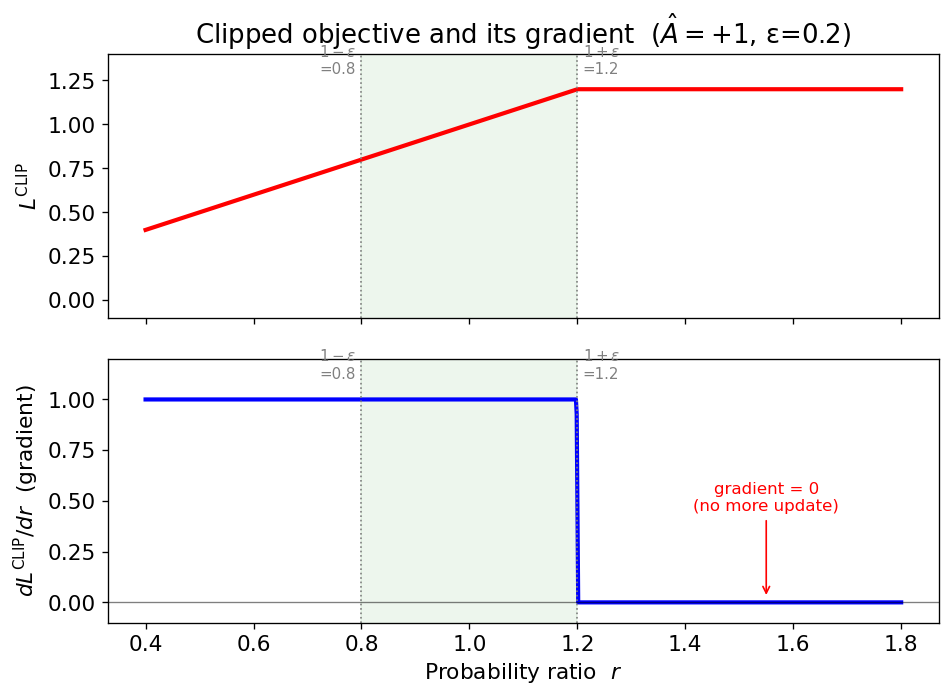

In [8]:
# Numerical check: compute the gradient of L^CLIP w.r.t. r
eps   = 0.2
r     = np.linspace(0.4, 1.8, 1000)
A_pos = 1.0

obj, _, _ = ppo_clip_objective(r, A_pos, eps)
grad = np.gradient(obj, r)   # numerical derivative dL/dr

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(r, obj,  'r-', lw=2.5)
axes[0].set_ylabel('$L^{\\mathrm{CLIP}}$')
axes[0].set_title('Clipped objective and its gradient  ($\hat{A}=+1$, ε=0.2)')
axes[0].fill_betweenx([-0.5, 1.5], 1-eps, 1+eps, alpha=0.07, color='green')
axes[0].axvline(1-eps, color='gray', ls=':', lw=1)
axes[0].axvline(1+eps, color='gray', ls=':', lw=1)
axes[0].set_ylim(-0.1, 1.4)

axes[1].plot(r, grad, 'b-', lw=2.5)
axes[1].axhline(0, color='black', lw=0.8, alpha=0.5)
axes[1].fill_betweenx([-0.2, 1.5], 1-eps, 1+eps, alpha=0.07, color='green')
axes[1].axvline(1-eps, color='gray', ls=':', lw=1)
axes[1].axvline(1+eps, color='gray', ls=':', lw=1)
axes[1].set_ylabel('$dL^{\\mathrm{CLIP}}/dr$  (gradient)')
axes[1].set_xlabel('Probability ratio  $r$')
axes[1].set_ylim(-0.1, 1.2)

for ax in axes:
    ax.text(1-eps - 0.01, ax.get_ylim()[1]*0.92, f'$1-\\varepsilon$\n={1-eps}',
            ha='right', fontsize=9, color='gray')
    ax.text(1+eps + 0.01, ax.get_ylim()[1]*0.92, f'$1+\\varepsilon$\n={1+eps}',
            ha='left', fontsize=9, color='gray')

axes[1].annotate('gradient = 0\n(no more update)', xy=(1.55, 0.02),
                 xytext=(1.55, 0.45), ha='center', fontsize=10, color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

## 4. Effect of ε on the Allowed Update Range

Larger $\varepsilon$ → wider allowed zone → larger policy updates per step (more aggressive, less stable).  
Smaller $\varepsilon$ → tighter zone → smaller updates (more conservative, more stable).

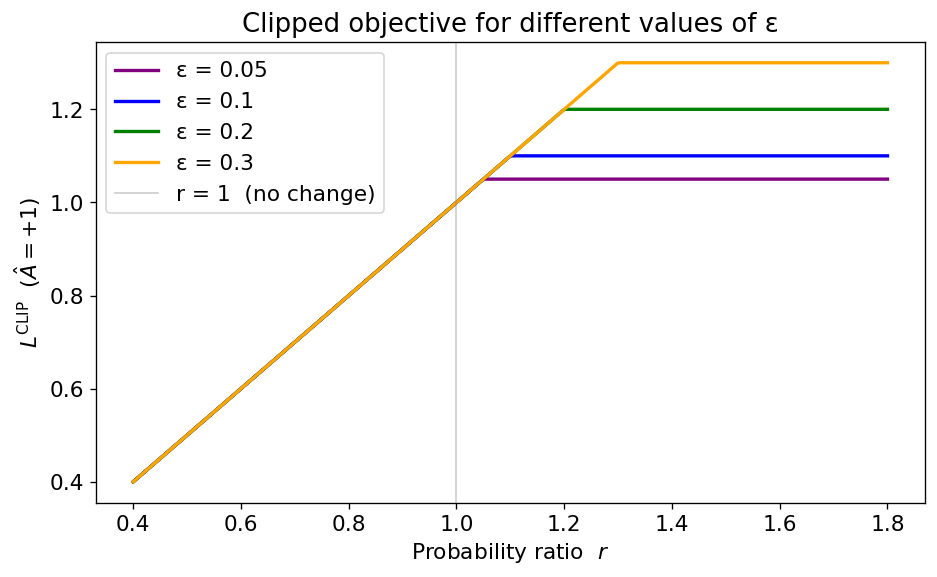

Flat (zero-gradient) region starts at r = 1 + ε:
  ε = 0.05  →  flat for r > 1.05
  ε = 0.10  →  flat for r > 1.10
  ε = 0.20  →  flat for r > 1.20
  ε = 0.30  →  flat for r > 1.30


In [9]:
r     = np.linspace(0.4, 1.8, 300)
A_hat = 1.0
epsilons = [0.05, 0.10, 0.20, 0.30]
colors   = ['purple', 'blue', 'green', 'orange']

fig, ax = plt.subplots(figsize=(8, 5))
for eps_val, col in zip(epsilons, colors):
    obj, _, _ = ppo_clip_objective(r, A_hat, eps_val)
    ax.plot(r, obj, color=col, lw=2, label=f'ε = {eps_val}')

ax.axvline(1.0, color='gray', lw=1, ls='-', alpha=0.4, label='r = 1  (no change)')
ax.set_xlabel('Probability ratio  $r$')
ax.set_ylabel('$L^{\\mathrm{CLIP}}$  ($\hat{A}=+1$)')
ax.set_title('Clipped objective for different values of ε')
ax.legend()
plt.tight_layout()
plt.show()

print("Flat (zero-gradient) region starts at r = 1 + ε:")
for eps_val in epsilons:
    print(f"  ε = {eps_val:.2f}  →  flat for r > {1+eps_val:.2f}")

## 5. Concrete Numerical Example

Suppose we are updating a single token with $\varepsilon = 0.2$ and advantage $\hat{A} = +1$.

| Scenario | $\pi_\theta$ | $\pi_{\theta_{\text{old}}}$ | $r$ | $r\hat{A}$ | clip$(r)\hat{A}$ | $L^{\text{CLIP}}$ | gradient? |
|---|---|---|---|---|---|---|---|
| policy barely changed | 0.30 | 0.30 | 1.00 | 1.00 | 1.00 | 1.00 | ✅ yes |
| policy increased a little | 0.36 | 0.30 | 1.20 | 1.20 | 1.20 | 1.20 | ✅ yes |
| policy increased too much | 0.42 | 0.30 | 1.40 | 1.40 | **1.20** | **1.20** | ❌ no (flat) |
| policy decreased a little | 0.27 | 0.30 | 0.90 | 0.90 | 0.90 | 0.90 | ✅ yes |
| policy decreased a lot | 0.15 | 0.30 | 0.50 | 0.50 | **0.80** | 0.50 | ✅ yes |

> **Note (last row):** clip(0.50, 0.8, 1.2) = **0.80** (clamped up to the lower bound), so the clipped term = 0.80.  
> But min(0.50, 0.80) = **0.50** — the *unclipped* term wins, so the gradient remains active and keeps pushing $r$ upward.

In [10]:
eps   = 0.2
A_hat = 1.0

scenarios = [
    ('policy barely changed',     0.30, 0.30),
    ('policy increased a little', 0.36, 0.30),
    ('policy increased too much', 0.42, 0.30),
    ('policy decreased a little', 0.27, 0.30),
    ('policy decreased a lot',    0.15, 0.30),
]

print(f"{'Scenario':<30} {'r':>6} {'r·Â':>8} {'clip·Â':>10} {'L_CLIP':>10} {'gradient?':>12}")
print('-' * 80)
for label, pi_new, pi_old in scenarios:
    r_val     = pi_new / pi_old
    unclipped = r_val * A_hat
    clipped   = np.clip(r_val, 1 - eps, 1 + eps) * A_hat
    L_clip    = min(unclipped, clipped)
    is_flat   = abs(r_val - np.clip(r_val, 1-eps, 1+eps)) > 1e-6 and A_hat * (r_val - np.clip(r_val,1-eps,1+eps)) > 0
    grad_str  = '❌ blocked' if is_flat else '✅ active'
    print(f"{label:<30} {r_val:>6.2f} {unclipped:>8.3f} {clipped:>10.3f} {L_clip:>10.3f} {grad_str:>12}")

Scenario                            r      r·Â     clip·Â     L_CLIP    gradient?
--------------------------------------------------------------------------------
policy barely changed            1.00    1.000      1.000      1.000     ✅ active
policy increased a little        1.20    1.200      1.200      1.200     ✅ active
policy increased too much        1.40    1.400      1.200      1.200    ❌ blocked
policy decreased a little        0.90    0.900      0.900      0.900     ✅ active
policy decreased a lot           0.50    0.500      0.800      0.500     ✅ active


## Summary

| Question | Answer |
|---|---|
| What is $r_t$? | Ratio of new vs old policy probability for the same token |
| What does `clip` do? | Clamps $r$ to $[1-\varepsilon, 1+\varepsilon]$, preventing extreme ratios |
| Why take `min`? | Ensures the objective is always a **pessimistic lower bound** — never rewards over-updating |
| When does the gradient vanish? | When the policy has already moved past the clip boundary in the direction of the advantage |
| What is $\varepsilon$ for? | Controls how large a policy update is allowed in one step (typical: 0.1–0.2) |

The clip function is not about limiting the loss value — it is about **zeroing the gradient** when the policy update is already large enough. This is what makes PPO stable.